# 산학프로젝트
**제조 공정 품질 불량 예측**

# 03 Baseline Modeling

## import

In [1]:
import pandas as pd
import numpy as np
import os

## 경로설정

In [2]:
os.chdir("data")

## 데이터 불러오기

In [3]:
labeled=pd.read_csv('labeled_data.csv', encoding='utf-8')

In [4]:
labeled.head()

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,...,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
0,5f8928bb9c0189cc666ef19b,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,...,24.799999,27.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5f8928de9c0189cc666ef20b,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.60,...,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5f8928df9c0189cc666ef213,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,...,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5f8928f39c0189cc666ef25e,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.59,...,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5f8928f59c0189cc666ef265,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,...,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 데이터 전처리

In [5]:
def info_df(df):
    info=pd.DataFrame(
        {
            "Columns": df.columns,
            "Non-Null Count": df.notna().sum().values,
            "Dtype": df.dtypes.values
        }
    )
    return info

In [6]:
info_df(labeled)

,Columns,Non-Null Count,Dtype
0,_id,7996,str
1,TimeStamp,7996,str
2,PART_FACT_PLAN_DATE,7996,str
3,PART_FACT_SERIAL,7996,int64
4,PART_NAME,7996,str
5,EQUIP_CD,7996,str
6,EQUIP_NAME,7996,str
7,PassOrFail,7996,str
8,Reason,71,str
9,Injection_Time,7996,float64


### 중복값 제거

In [7]:
labeled.duplicated().sum()

np.int64(2764)

In [8]:
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)
drop_dup.shape

(5232, 45)

In [10]:
# Part 종류 확인: CN7 RG3이 대부분이라 나머지 2건 삭제
drop_dup['PART_NAME'].value_counts()

PART_NAME
CN7 W/S SIDE MLD'G RH        1989
CN7 W/S SIDE MLD'G LH        1985
RG3 MOLD'G W/SHLD, LH         628
RG3 MOLD'G W/SHLD, RH         628
SP2 CVR ROOF RACK CTR, RH       1
JX1 W/S SIDE MLD'G RH           1
Name: count, dtype: int64

### CN7, RG3 제외 삭제

In [11]:
# CN7, RG3만 활용
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

In [12]:
drop_part.shape

(5230, 45)

### 불필요한 변수 삭제

In [13]:
drop_part.columns

Index(['_id', 'TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
       'PART_NAME', 'EQUIP_CD', 'EQUIP_NAME', 'PassOrFail', 'Reason',
       'Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time',
       'Clamp_Close_Time', 'Cushion_Position', 'Switch_Over_Position',
       'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed',
       'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure',
       'Max_Switch_Over_Pressure', 'Max_Back_Pressure',
       'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2',
       'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5',
       'Barrel_Temperature_6', 'Barrel_Temperature_7', 'Hopper_Temperature',
       'Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_3',
       'Mold_Temperature_4', 'Mold_Temperature_5', 'Mold_Temperature_6',
       'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9',
       'Mold_Temperature_10', 'Mold_Temperature_11', 

In [53]:
# 불필요한 컬럼 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2',
               'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
               'PART_NAME', 'Reason', 'Switch_Over_Position', 'TimeStamp', '_id']

final_df=drop_part.drop(columns=drop_columns)

In [54]:
final_df.shape

(5230, 25)

In [55]:
final_df.head()

,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,Y,9.59,4.47,16.92,59.520000,7.13,653.409973,68.849998,647.98999,55.400002,...,59.299999,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,66.300003,24.799999,27.5
1,Y,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,...,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
2,Y,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,...,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
3,Y,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,...,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6
4,Y,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,...,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6


### PassOrFail 인코딩

In [56]:
final_df['PassOrFail']=final_df['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

### 데이터 분할

In [57]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(final_df.drop(columns='PassOrFail'), final_df['PassOrFail'], test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(4184, 24) (4184,)
(1046, 24) (1046,)


### 데이터 스케일링

In [58]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

## 모델링

### Base Model

In [59]:
model_dict={}

In [60]:
from sklearn import set_config
set_config(display='text')

# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=1000, random_state=0)
rf.fit(x_train_scaled, y_train)
model_dict['RandomForest']=rf

# Bagging
from sklearn.ensemble import BaggingClassifier

bag=BaggingClassifier(n_estimators=1000, random_state=0)
bag.fit(x_train_scaled, y_train)
model_dict['Bagging']=bag

# XGBoost
from xgboost import XGBClassifier

xgb=XGBClassifier(n_estimators=1000, random_state=0)
xgb.fit(x_train_scaled, y_train)
model_dict['XGBoost']=xgb

In [61]:
result_df=pd.DataFrame(columns=['Model', 'Defect Precision', 'Defect Recall', 'Defect F1 Score', 'Average Precision'])

RandomForest
Accuracy: 0.9818355640535373
Average Precision: 0.4529455893099395
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.29      0.42      0.34        12

    accuracy                           0.98      1046
   macro avg       0.64      0.70      0.67      1046
weighted avg       0.99      0.98      0.98      1046

Bagging
Accuracy: 0.9837476099426387
Average Precision: 0.4444075082073809
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12

    accuracy                           0.98      1046
   macro avg       0.68      0.79      0.72      1046
weighted avg       0.99      0.98      0.99      1046

XGBoost
Accuracy: 0.9837476099426387
Average Precision: 0.2691094415953129
Classification Report
              precision    recall  f1-score   supp

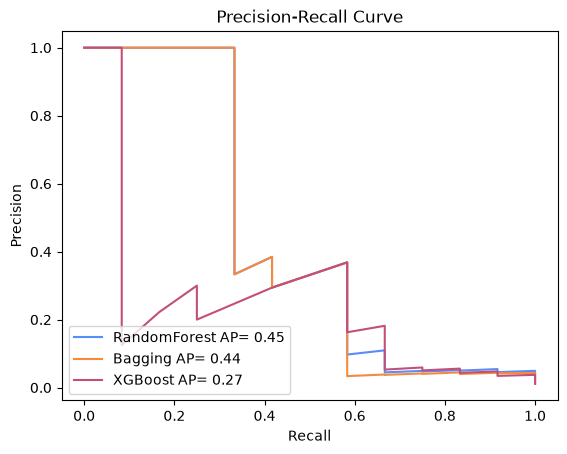

In [62]:
# 저장한 학습 모델 불러와서 예측
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report
plt.figure()
for model in model_dict:
    x_pred=model_dict[model].predict(x_test_scaled)
    y_prob=model_dict[model].predict_proba(x_test_scaled)
    acc=model_dict[model].score(x_test_scaled, y_test)
    ap_score=average_precision_score(y_test, y_prob[:, 1])
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob[:, 1])

    print("=" * 80)
    print(model)
    print("=" * 80)
    print(f'Accuracy: {acc}')
    print(f'Average Precision: {ap_score}')
    print("Classification Report")
    print(classification_report(y_test, x_pred, target_names=['양품', '불량']))
    plt.plot(recall, precision, label=f'{model} AP= {ap_score:.2f}')

    report=classification_report(y_test, x_pred, target_names=['양품', '불량'], output_dict=True)
    precision_defect=report['불량']['precision']
    recall_defect=report['불량']['recall']
    f1_defect=report['불량']['f1-score']
    result_dict={'Model': f'{model} Baseline', 'Defect Precision': precision_defect, 'Defect Recall': recall_defect,
              'Defect F1 Score': f1_defect, 'Average Precision': ap_score}
    df=pd.DataFrame([result_dict])
    result_df=pd.concat([result_df, df], ignore_index=True)


plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

In [64]:
importance_df=pd.DataFrame({'Feature':x_train.columns, 'Importance':model_dict['RandomForest'].feature_importances_}).sort_values('Importance', ascending=False)
importance_df

,Feature,Importance
5,Cushion_Position,0.061441
15,Barrel_Temperature_1,0.059892
8,Max_Injection_Speed,0.058405
12,Max_Switch_Over_Pressure,0.055825
18,Barrel_Temperature_4,0.053507
21,Hopper_Temperature,0.051809
23,Mold_Temperature_4,0.049464
14,Average_Back_Pressure,0.048168
2,Plasticizing_Time,0.047535
11,Max_Injection_Pressure,0.045731


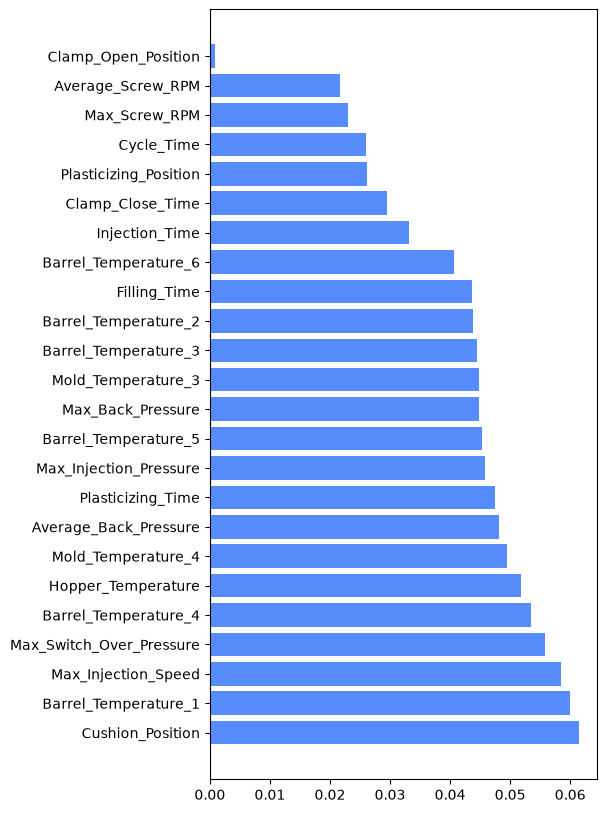

In [65]:
plt.figure(figsize=(5, 10))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.show()

In [66]:
result_df

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
0,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
0,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109


In [67]:
result_df.to_csv('03_Baseline_Modeling_Result.csv', index=False)